In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
!git config --global user.email "spoorthyece@gmail.com"
!git config --global user.name "Spoorthy2001"

# Predicting RUL for NASA CMAPSS

#### Note - working on data FD001

## Imports

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

## Loading data

In [44]:
DATAPATH = "drive/MyDrive/ml_as_beginner/projects/hence_proved/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData"
COLUMN = ['unit', 'cycle', 'op1', 'op2', 'op3']
sensor_data_columns = [f"s{i}" for i in range(1, 22)]
COLUMN = COLUMN + sensor_data_columns

print(len(COLUMN))

26


In [45]:
def load_data(data_type, path, dataset):

  if not all([path, data_type, dataset]):
    raise ValueError("path, type, and dataset must all be non-empty")
  col_names = ["RUL"] if data_type == "RUL" else COLUMN
  df = pd.read_csv(f"{path}/{data_type}_{dataset}.txt", sep=r'\s+', header=None, names=col_names).dropna(axis=1)

  return df



In [46]:
train = load_data("train", DATAPATH, "FD001")
test = load_data("test", DATAPATH, "FD001")
rul = load_data("RUL", DATAPATH, "FD001")


## EDA

In [47]:
train.describe()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [48]:
train[['unit', 'cycle']].describe()

,unit,cycle
count,20631.000000,20631.000000
mean,51.506568,108.807862
std,29.227633,68.880990
min,1.000000,1.000000
25%,26.000000,52.000000
50%,52.000000,104.000000
75%,77.000000,156.000000
max,100.000000,362.000000


In [49]:
train[['unit', 'cycle']].groupby('unit').max()

,cycle
unit,
1,192
2,287
3,179
4,189
5,269
...,...
96,336
97,202
98,156


In [50]:
train[['op1', 'op2', 'op3']].describe()

,op1,op2,op3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


In [51]:
data_description = train[sensor_data_columns].describe().transpose()
# data_description[data_description['std'] > 0]

### Calculating RUL

In [52]:
def calculate_rul(df):
  max_cycles = df.groupby('unit')['cycle'].max().reset_index()
  max_cycles.columns = ['unit', 'max_cycle']
  df = df.merge(max_cycles, on='unit')
  df['rul'] = df['max_cycle'] - df['cycle']
  df = df.drop('max_cycle', axis=1)
  return df

train = calculate_rul(train)
# train.head()

### Plotting the RUL

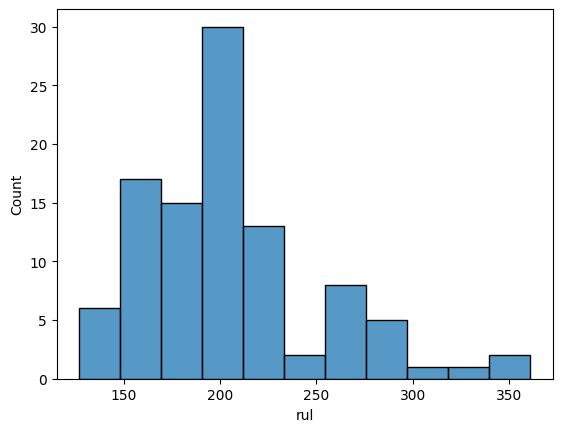

In [53]:
df_rul_engine = train[['unit', 'rul']].groupby('unit').max().reset_index()
sns.histplot(data=df_rul_engine, x='rul')
plt.show()


### Dropping all the constant value columns

In [54]:
def remove_columns(df):
  df_copy = df.describe().transpose()
  remove = df_copy[df_copy['std'] < 0.001].index.tolist()
  return remove


numerical_columns = ['op1', 'op2', 'op3'] + sensor_data_columns
# columns_to_remove = remove_columns(train[numerical_columns])
cols_to_remove = remove_columns(train[numerical_columns])
cols_to_remove = cols_to_remove + ['op1']
train = train.drop(cols_to_remove, axis=1)

In [55]:
train.head()
train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,29.227633,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,68.880990,1.0000,52.0000,104.0000,156.0000,362.0000
s2,20631.0,642.680934,0.500053,641.2100,642.3250,642.6400,643.0000,644.5300
s3,20631.0,1590.523119,6.131150,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s4,20631.0,1408.933782,9.000605,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s6,20631.0,21.609803,0.001389,21.6000,21.6100,21.6100,21.6100,21.6100
s7,20631.0,553.367711,0.885092,549.8500,552.8100,553.4400,554.0100,556.0600
s8,20631.0,2388.096652,0.070985,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
s9,20631.0,9065.242941,22.082880,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
s11,20631.0,47.541168,0.267087,46.8500,47.3500,47.5100,47.7000,48.5300
